In [1]:
#Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import duckdb as ddb
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

In [2]:
#Cargar los datasets
survey = pd.read_csv(r"C:\Users\angel\OneDrive\Documentos\Data_Analysis\Proyectos\mentalhealth_music\survey_results.csv")
music = pd.read_csv(r"C:\Users\angel\OneDrive\Documentos\Data_Analysis\Proyectos\mentalhealth_music\dataset.csv")


In [3]:
survey.info()

<class 'pandas.DataFrame'>
RangeIndex: 736 entries, 0 to 735
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Timestamp                     736 non-null    str    
 1   Age                           735 non-null    float64
 2   Primary streaming service     735 non-null    str    
 3   Hours per day                 736 non-null    float64
 4   While working                 733 non-null    str    
 5   Instrumentalist               732 non-null    str    
 6   Composer                      735 non-null    str    
 7   Fav genre                     736 non-null    str    
 8   Exploratory                   736 non-null    str    
 9   Foreign languages             732 non-null    str    
 10  BPM                           629 non-null    float64
 11  Frequency [Classical]         736 non-null    str    
 12  Frequency [Country]           736 non-null    str    
 13  Frequency [EDM] 

In [4]:
#Estandarización de variables
survey.columns = survey.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('[', '').str.replace(']', '')


In [5]:
#Eliminar columnas no relevantes
survey = survey.drop(columns=['timestamp',
                                    'permissions', 
                                    'frequency_country', 
                                    'frequency_edm',
                                    'frequency_classical', 
                                    'frequency_folk',
                                    'frequency_gospel',
                                    'frequency_k_pop',
                                    'frequency_latin',
                                    'frequency_metal',
                                    'frequency_lofi',
                                    'frequency_r&b',
                                    'frequency_rap',
                                    'frequency_hip_hop', 
                                    'frequency_jazz',
                                    'frequency_pop',
                                    'frequency_rock',
                                    'frequency_video_game_music'])

In [6]:
survey.rename(columns={'primary_streaming_service': 'streaming'}, inplace=True)

In [7]:
survey.value_counts('fav_genre')

fav_genre
Rock                188
Pop                 114
Metal                88
Classical            53
Video game music     44
EDM                  37
R&B                  35
Hip hop              35
Folk                 30
K pop                26
Country              25
Rap                  22
Jazz                 20
Lofi                 10
Gospel                6
Latin                 3
Name: count, dtype: int64

In [8]:
music.info()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          114000 non-nu

In [9]:
#music =music.drop(columns=['track_id', 'Unnamed: 0', 'time_signature', 'mode', 'acousticness', 'liveness','track_name', 'album_name'])

In [10]:
# En el dataset de la Encuesta
survey['fav_genre'] = survey['fav_genre'].str.lower().str.strip().str.replace(' ', '_').str.replace('-', '_')
# En el dataset de Spotify
music['track_genre'] = music['track_genre'].str.lower().str.strip().str.replace(' ', '_').str.replace('-', '_') 

In [11]:
music.value_counts('track_genre')

track_genre
acoustic       1000
afrobeat       1000
alt_rock       1000
alternative    1000
ambient        1000
               ... 
techno         1000
trance         1000
trip_hop       1000
turkish        1000
world_music    1000
Name: count, Length: 114, dtype: int64

In [12]:
music.columns

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='str')

In [13]:
# Promedios por género (danceability, energy, valence) usando `comparacion`
promedios_por_genero = music.groupby('track_genre')[['danceability', 'energy', 'valence','loudness','speechiness','instrumentalness']].mean().reset_index()

print(promedios_por_genero)

     track_genre  danceability    energy   valence   loudness  speechiness  \
0       acoustic      0.549593  0.435368  0.424023  -9.447843     0.043247   
1       afrobeat      0.669580  0.702812  0.698619  -7.789353     0.086579   
2       alt_rock      0.534493  0.754173  0.518260  -6.191489     0.055071   
3    alternative      0.559927  0.720030  0.495570  -6.078777     0.070101   
4        ambient      0.367867  0.237162  0.167498 -18.601365     0.041562   
..           ...           ...       ...       ...        ...          ...   
109       techno      0.684348  0.746413  0.321878  -8.077874     0.064212   
110       trance      0.583409  0.845272  0.276881  -6.329711     0.079705   
111     trip_hop      0.634695  0.622363  0.478069  -9.239915     0.076303   
112      turkish      0.616077  0.609804  0.462314  -8.224722     0.105087   
113  world_music      0.414572  0.532987  0.250295  -9.417547     0.041768   

     instrumentalness  
0            0.038336  
1            0.

In [14]:
music['promedios_por_genero'] = music['track_genre']                                                                              

In [15]:
correccion = {'video_game_music' : 'gaming', 'r&b': 'rnb', 'rap': 'hip_hop','k_pop': 'pop' }

In [16]:
# Consulta en SQL con DuckDB para unir los datasets
query = """
SELECT 
    s.*, 
    a.danceability, 
    a.energy, 
    a.valence,
    a.loudness,
    a.speechiness,
    a.instrumentalness 
    
    
FROM survey s

INNER JOIN promedios_por_genero a 
    ON s.fav_genre = a.track_genre
"""

# Ejecutamos con DuckDB
master_data = ddb.query(query).to_df()


In [17]:
print(master_data.info())
print(master_data.shape)
print(master_data.head(3))  
print(master_data.describe())

<class 'pandas.DataFrame'>
RangeIndex: 625 entries, 0 to 624
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                624 non-null    float64
 1   streaming          624 non-null    str    
 2   hours_per_day      625 non-null    float64
 3   while_working      622 non-null    str    
 4   instrumentalist    622 non-null    str    
 5   composer           624 non-null    str    
 6   fav_genre          625 non-null    str    
 7   exploratory        625 non-null    str    
 8   foreign_languages  621 non-null    str    
 9   bpm                532 non-null    float64
 10  anxiety            625 non-null    float64
 11  depression         625 non-null    float64
 12  insomnia           625 non-null    float64
 13  ocd                625 non-null    float64
 14  music_effects      617 non-null    str    
 15  danceability       625 non-null    float64
 16  energy             625 non-null    fl

In [18]:
# Comprobamos que no haya valores vacíos en las nuevas columnas
nulos_musica = master_data['energy'].isnull().sum()
print(f"Valores vacíos en energía: {nulos_musica}")

# Vemos cuántas personas quedaron por cada género
print("\nConteo de personas por género en el nuevo dataset:")
print(master_data[['fav_genre']].value_counts())

Valores vacíos en energía: 0

Conteo de personas por género en el nuevo dataset:
fav_genre
rock         188
pop          114
metal         88
classical     53
edm           37
hip_hop       35
folk          30
k_pop         26
country       25
jazz          20
gospel         6
latin          3
Name: count, dtype: int64


In [19]:
master_data = ddb.query(query).to_df()
print(f"Nuevo total de filas: {len(master_data)}")

Nuevo total de filas: 625


In [20]:
print(master_data.info())

<class 'pandas.DataFrame'>
RangeIndex: 625 entries, 0 to 624
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                624 non-null    float64
 1   streaming          624 non-null    str    
 2   hours_per_day      625 non-null    float64
 3   while_working      622 non-null    str    
 4   instrumentalist    622 non-null    str    
 5   composer           624 non-null    str    
 6   fav_genre          625 non-null    str    
 7   exploratory        625 non-null    str    
 8   foreign_languages  621 non-null    str    
 9   bpm                532 non-null    float64
 10  anxiety            625 non-null    float64
 11  depression         625 non-null    float64
 12  insomnia           625 non-null    float64
 13  ocd                625 non-null    float64
 14  music_effects      617 non-null    str    
 15  danceability       625 non-null    float64
 16  energy             625 non-null    fl

In [21]:
master_data.to_csv('master_data.csv', index=False)

In [22]:
# Seleccionamos solo las columnas demográficas y de uso
demograficos = master_data[['age', 'hours_per_day']]

# Obtenemos las estadísticas básicas
print(demograficos.describe())

              age  hours_per_day
count  624.000000     625.000000
mean    25.625000       3.553280
std     12.049673       2.919939
min     10.000000       0.000000
25%     18.000000       2.000000
50%     21.000000       3.000000
75%     29.000000       5.000000
max     80.000000      24.000000


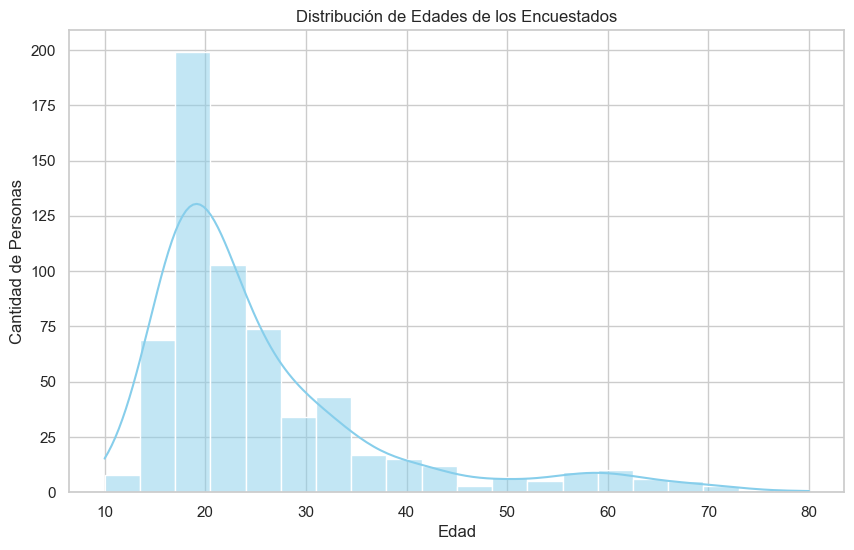

La edad promedio es: 25.6 años


In [23]:
#Histograma de edades
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.histplot(master_data['age'].dropna(), bins=20, kde=True, color='skyblue')

plt.title('Distribución de Edades de los Encuestados')
plt.xlabel('Edad')
plt.ylabel('Cantidad de Personas')
plt.show()

# Imprimimos el promedio exacto para tener el dato técnico
print(f"La edad promedio es: {master_data['age'].mean():.1f} años")

Text(0, 0.5, 'Cantidad de Personas')

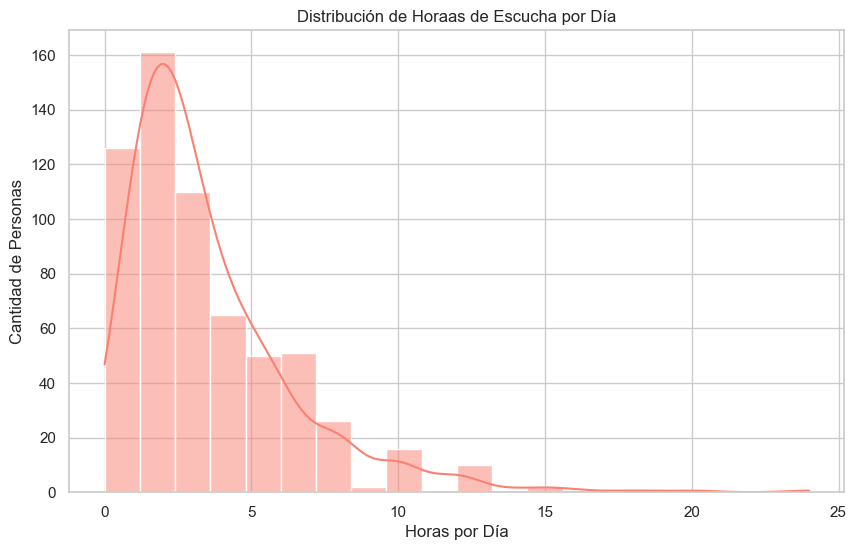

In [24]:
#Histograma de horas por día

plt.figure(figsize=(10, 6))
sns.histplot(master_data['hours_per_day'].dropna(), bins=20, kde=True, color='salmon')

plt.title('Distribución de Horaas de Escucha por Día')
plt.xlabel('Horas por Día')
plt.ylabel('Cantidad de Personas')


C:\Users\angel\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\angel\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127925 (\N{MUSICAL NOTE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


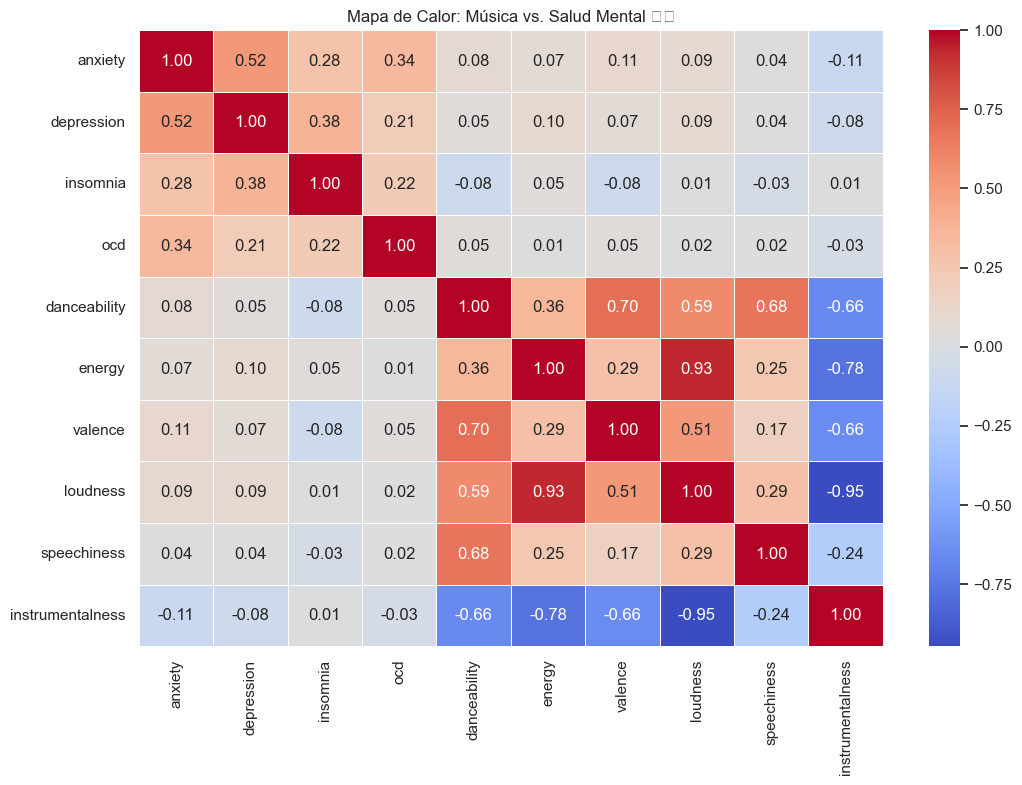

In [25]:
#Matriz de correlación entre trastornos y características de la música

columnas_analisis = [
    'anxiety', 'depression', 'insomnia', 'ocd', 
    'danceability', 'energy', 'valence', 'loudness', 'speechiness', 'instrumentalness'
]
corr_matrix = master_data[columnas_analisis].corr()


plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Mapa de Calor: Música vs. Salud Mental 🧠🎵')
plt.show()

In [26]:
# Definimos las columnas que mencionamos antes
columnas_estudio = [
    'anxiety', 'depression', 'insomnia', 'ocd', 
    'danceability', 'energy', 'loudness', 'speechiness', 'instrumentalness'
]

# Creamos un nuevo DataFrame solo con esas columnas y sin valores nulos
data_cluster = master_data[columnas_estudio].dropna()

# Verificamos cuántas filas nos quedaron después de la limpieza
print(f"Total de registros para el análisis: {len(data_cluster)}")

Total de registros para el análisis: 625


In [27]:
# 1. Inicializamos el escalador
scaler = MinMaxScaler()

# 2. Ajustamos y transformamos los datos
# Esto convierte nuestra tabla en una matriz de números entre 0 y 1
data_scaled = scaler.fit_transform(data_cluster)

# 3. (Opcional) Convertirlo de nuevo a DataFrame para verlo claro

data_scaled_df = pd.DataFrame(data_scaled, columns=columnas_estudio)
print(data_scaled_df.head())

   anxiety  depression  insomnia  ocd  danceability    energy  loudness  \
0      0.3         0.0       0.1  0.0      0.959766  0.825976  1.000000   
1      0.7         0.2       0.2  0.1      0.456443  0.752167  0.905865   
2      0.9         0.7       0.3  0.3      0.361493  0.250793  0.575640   
3      0.8         0.8       0.7  0.7      0.361493  0.250793  0.575640   
4      0.5         0.3       0.5  0.3      0.750383  0.746914  0.918881   

   speechiness  instrumentalness  
0     0.582070          0.009531  
1     0.097124          0.028692  
2     0.154264          0.123809  
3     0.154264          0.123809  
4     0.524835          0.010589  


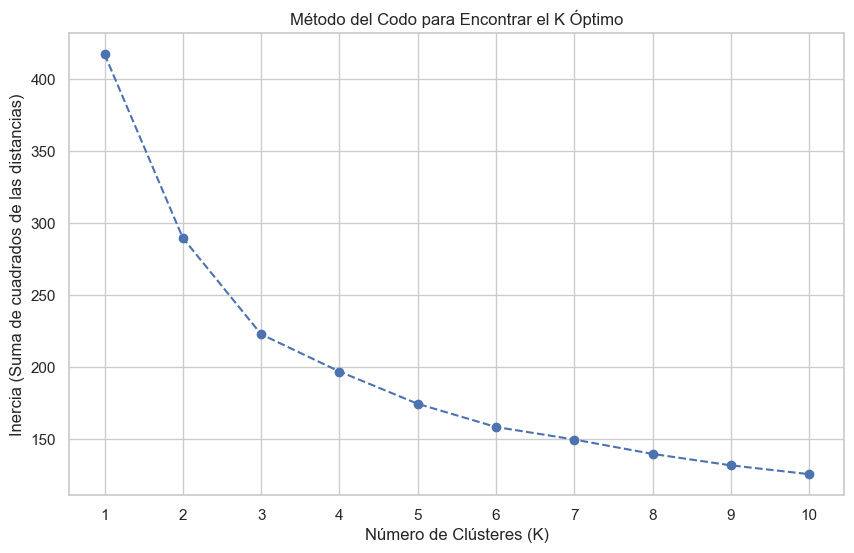

In [28]:

# 1. Creamos una lista para guardar los valores de inercia
inercia = []
rango_k = range(1, 11)

# 2. Ejecutamos el algoritmo para diferentes valores de K
for k in rango_k:
    # Usamos n_init=10 para asegurar que el algoritmo pruebe varias posiciones iniciales
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(data_scaled)
    inercia.append(kmeans.inertia_)

# 3. Graficamos los resultados
plt.figure(figsize=(10, 6))
plt.plot(rango_k, inercia, marker='o', linestyle='--', color='b')
plt.title('Método del Codo para Encontrar el K Óptimo')
plt.xlabel('Número de Clústeres (K)')
plt.ylabel('Inercia (Suma de cuadrados de las distancias)')
plt.xticks(rango_k)
plt.grid(True)
plt.show()

In [29]:
# 1. Configuramos el modelo específicamente para 3 grupos
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)

# 2. Entrenamos y asignamos las etiquetas (0, 1 o 2)
clusters = kmeans_final.fit_predict(data_scaled)

# 3. Guardamos estas etiquetas en nuestro DataFrame original
data_cluster['perfil_usuario'] = clusters

# 4. Ahora sí, calculamos los promedios de estos 3 perfiles
resumen_grupos = data_cluster.groupby('perfil_usuario').mean()
print(resumen_grupos)

                 anxiety  depression  insomnia       ocd  danceability  \
perfil_usuario                                                           
0               4.886792    4.075472  3.792453  2.377358      0.381923   
1               7.598361    6.832787  5.486885  3.727869      0.570289   
2               4.146067    2.790262  1.850187  1.397004      0.574611   

                  energy   loudness  speechiness  instrumentalness  
perfil_usuario                                                      
0               0.189827 -20.145216     0.050831          0.619208  
1               0.676491  -6.674269     0.067277          0.028305  
2               0.666069  -6.756495     0.067664          0.026414  


In [30]:
# 1. Terminamos de ejecutar el modelo y predecir los grupos
clusters = kmeans_final.fit_predict(data_scaled)

# 2. Añadimos la columna de resultados al DataFrame que tiene los datos originales (sin escalar)
# Es mejor usar el DataFrame original para que los promedios sean fáciles de leer (ej. ansiedad de 0 a 10)
data_cluster['perfil_usuario'] = clusters

# 3. Revisamos cuántos usuarios hay en cada grupo
print("Conteo de usuarios por grupo:")
print(data_cluster['perfil_usuario'].value_counts())

# 4. Calculamos los promedios para empezar el perfilamiento
resumen_grupos = data_cluster.groupby('perfil_usuario').mean()
print("\nPromedios por perfil:")
print(resumen_grupos)

Conteo de usuarios por grupo:
perfil_usuario
1    305
2    267
0     53
Name: count, dtype: int64

Promedios por perfil:
                 anxiety  depression  insomnia       ocd  danceability  \
perfil_usuario                                                           
0               4.886792    4.075472  3.792453  2.377358      0.381923   
1               7.598361    6.832787  5.486885  3.727869      0.570289   
2               4.146067    2.790262  1.850187  1.397004      0.574611   

                  energy   loudness  speechiness  instrumentalness  
perfil_usuario                                                      
0               0.189827 -20.145216     0.050831          0.619208  
1               0.676491  -6.674269     0.067277          0.028305  
2               0.666069  -6.756495     0.067664          0.026414  


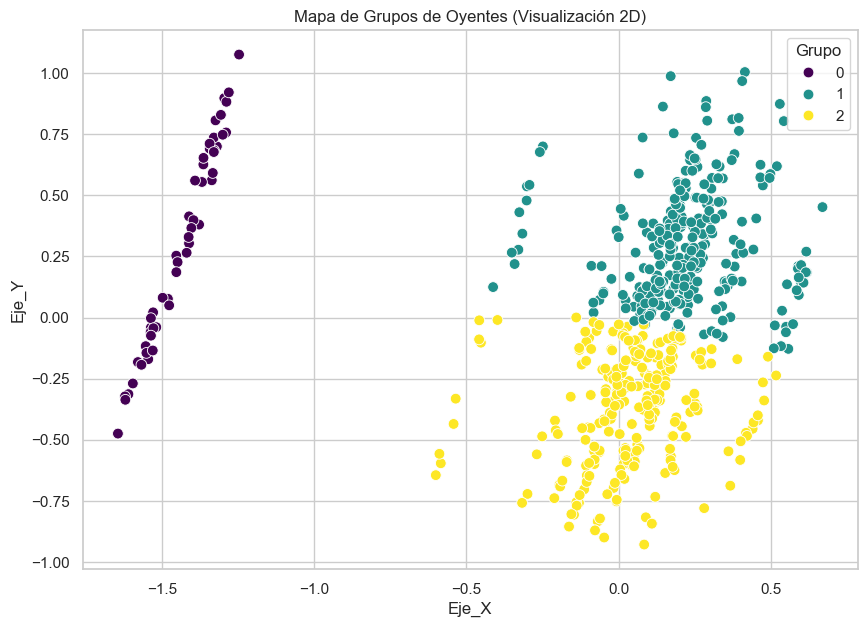

In [31]:
from sklearn.decomposition import PCA
import seaborn as sns

# 1. Reducimos las 9 variables a solo 2 dimensiones (PC1 y PC2)
pca = PCA(n_components=2)
puntos_2d = pca.fit_transform(data_scaled)

# 2. Creamos un DataFrame para graficar
df_visual = pd.DataFrame(puntos_2d, columns=['Eje_X', 'Eje_Y'])
df_visual['Grupo'] = clusters

# 3. Dibujamos la gráfica de dispersión
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_visual, x='Eje_X', y='Eje_Y', hue='Grupo', palette='viridis', s=60)
plt.title('Mapa de Grupos de Oyentes (Visualización 2D)')
plt.show()

In [38]:
data_cluster.head()

,anxiety,depression,insomnia,ocd,danceability,energy,loudness,speechiness,instrumentalness,perfil_usuario
0,3.0,0.0,1.0,0.0,0.721902,0.727080,-5.263596,0.093123,0.009177,2
1,7.0,2.0,2.0,1.0,0.543609,0.679071,-6.664481,0.049923,0.020978,2
2,9.0,7.0,3.0,3.0,0.509975,0.352954,-11.578765,0.055013,0.079561,1
3,8.0,8.0,7.0,7.0,0.509975,0.352954,-11.578765,0.055013,0.079561,1
4,5.0,3.0,5.0,3.0,0.647732,0.675654,-6.470775,0.088025,0.009828,2


In [39]:
# Añadir la columna `fav_genre` desde `master_data` alineando por índice
data_cluster['fav_genre'] = master_data.loc[data_cluster.index, 'fav_genre']

# Mostrar comprobación rápida
data_cluster.head()

,anxiety,depression,insomnia,ocd,danceability,energy,loudness,speechiness,instrumentalness,perfil_usuario,fav_genre
0,3.0,0.0,1.0,0.0,0.721902,0.727080,-5.263596,0.093123,0.009177,2,latin
1,7.0,2.0,2.0,1.0,0.543609,0.679071,-6.664481,0.049923,0.020978,2,rock
2,9.0,7.0,3.0,3.0,0.509975,0.352954,-11.578765,0.055013,0.079561,1,jazz
3,8.0,8.0,7.0,7.0,0.509975,0.352954,-11.578765,0.055013,0.079561,1,jazz
4,5.0,3.0,5.0,3.0,0.647732,0.675654,-6.470775,0.088025,0.009828,2,k_pop


In [37]:
# 1. Creamos una tabla cruzada (frecuencia de géneros por grupo)
tabla_generos = pd.crosstab(data_cluster['perfil_usuario'], data_cluster['fav_genre'])

# 2. Visualizamos con Seaborn (que es más estable para portafolios estáticos)
plt.figure(figsize=(12, 8))
sns.heatmap(tabla_generos, annot=True, cmap="YlGnBu", fmt='d')

plt.title('Mapa de Calor: Géneros Favoritos por Perfil de Usuario')
plt.xlabel('Género Musical')
plt.ylabel('Perfil (Clúster)')
plt.show()

KeyError: 'fav_genre'